In [1]:
import numpy as np
import matplotlib.pyplot as plt
from  matplotlib import patches
from scipy import signal
from scipy.signal import butter, sosfilt, sosfreqz
from scipy.io import wavfile
from IPython.display import Audio
%config InlineBackend.figure_format ='retina'
import matplotlib
figsize=(10,5)
matplotlib.rcParams.update({'font.size': 16})
import soundfile as sf

In [2]:
def plot_spec(x, Fs, max_freq=None, do_fft=True):
    C = int(len(x) / 2)  # positive frequencies only
    if max_freq:
        C = int(C * max_freq / float(Fs) * 2) 
    X = np.abs(np.fft.fft(x)[0:C]) if do_fft else x[0:C]
    N = Fs * np.arange(0, C) / len(x);
    plt.plot(N, X)
    plt.grid()
    return N, X

Text(0.5, 1.0, 'Butterworth Filter')

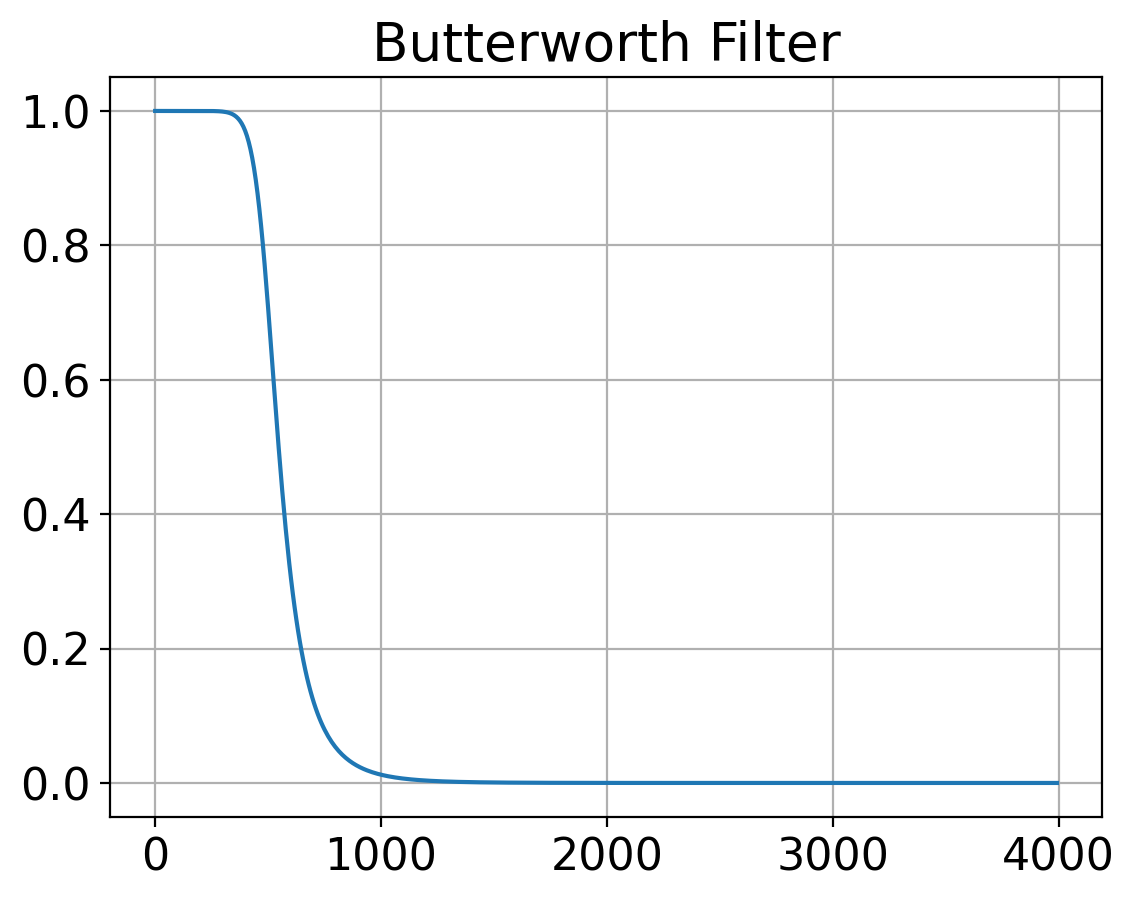

In [5]:
b, a = butter(6, 500,'lp',fs=8000)
w, h = signal.freqz(b, a)
plt.plot(w[:]/np.pi * 4000 ,abs(h[:]))
plt.grid()
plt.title("Butterworth Filter")

 The impule response for ideal LP filter with $\omega_c$ as the cutoff frequency is: $$ h[n]=\frac{\sin(\omega_c n)}{\pi n} $$
 let us truncate this.
 The normalized sinc function is equal to $$sinc(x) = \frac{\sin(\pi x)}{\pi x}$$ 

 

In [8]:
h = [1/12*np.sinc(n/12) for n in np.arange(-100,100)]
w = np.hamming(len(h))
h = h*w

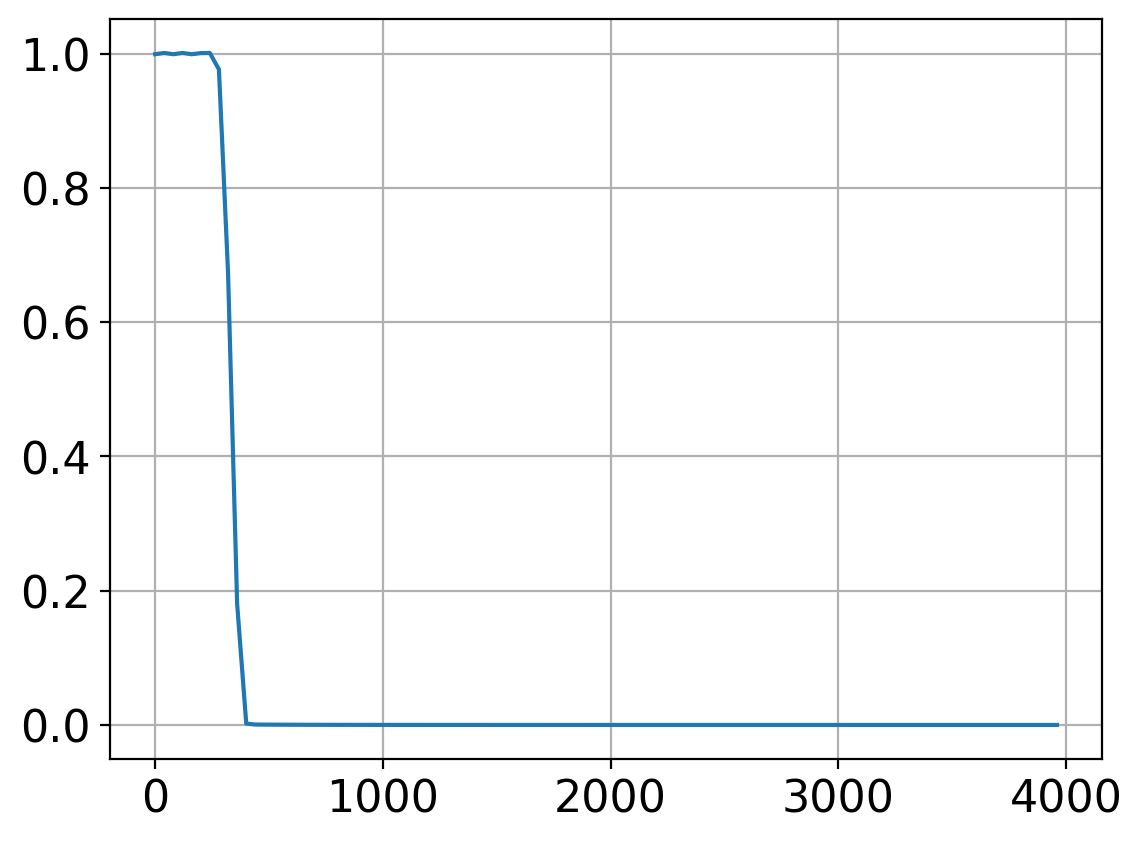

In [9]:
plot_spec(h,8000);

### Now construct a bp filter:

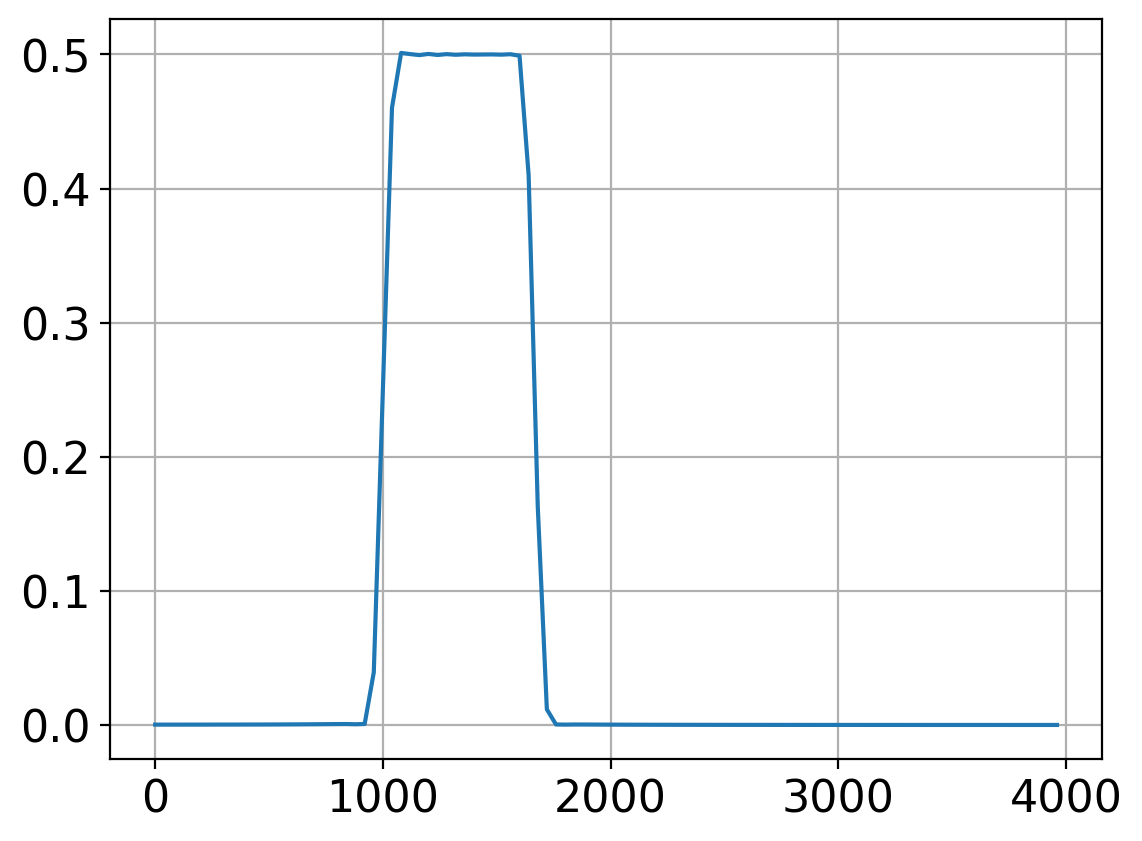

In [11]:
m = np.cos(np.pi/3*np.arange(len(h))) # modulate h shift spectrum
bp = m*h
plot_spec(bp,8000);

In [16]:
data = np.arange(1,25).astype(np.uint8)

In [18]:
wavfile.write("test.wav",8000,data)

In [20]:
import pydub


In [24]:
from numpy import pi,sin
sig =  sin(2*pi*440/48000 *np.arange(48000))
sf.write("tone.wav",sig,48000)
len(sig)

48000

In [26]:
!play tone.wav



tone.wav:

 File Size: 96.0k     Bit Rate: 768k
  Encoding: Signed PCM    
  Channels: 1 @ 16-bit   
Samplerate: 48000Hz      
Replaygain: off         
  Duration: 00:00:01.00  

In:100%  00:00:01.00 [00:00:00.00] Out:48.0k [      |      ] Hd:0.0 Clip:0    
Done.


In [28]:
from pydub import AudioSegment

audio = AudioSegment.from_file("tone.wav")


In [30]:

samples = np.array(audio.get_array_of_samples())


In [32]:
Audio(sig,rate=48000)

In [149]:
audio.export("tone.mp3")

<_io.BufferedRandom name='tone.mp3'>

In [34]:
l=np.logspace(2, 14, 9, base=2)

In [36]:
print([f"{x:.0f}" for x in l])


['4', '11', '32', '91', '256', '724', '2048', '5793', '16384']


In [40]:
2**14

16384

In [42]:

from scipy.signal import chirp

# Parameters
duration = 2.0  # seconds
fs = 44100      # sample rate (Hz)
t = np.linspace(0, duration, int(fs * duration))

# Generate chirp: linear sweep from 100 Hz to 2000 Hz
signal = chirp(t, f0=100, f1=2000, t1=duration, method='linear')



In [46]:
Audio(signal,rate=fs)

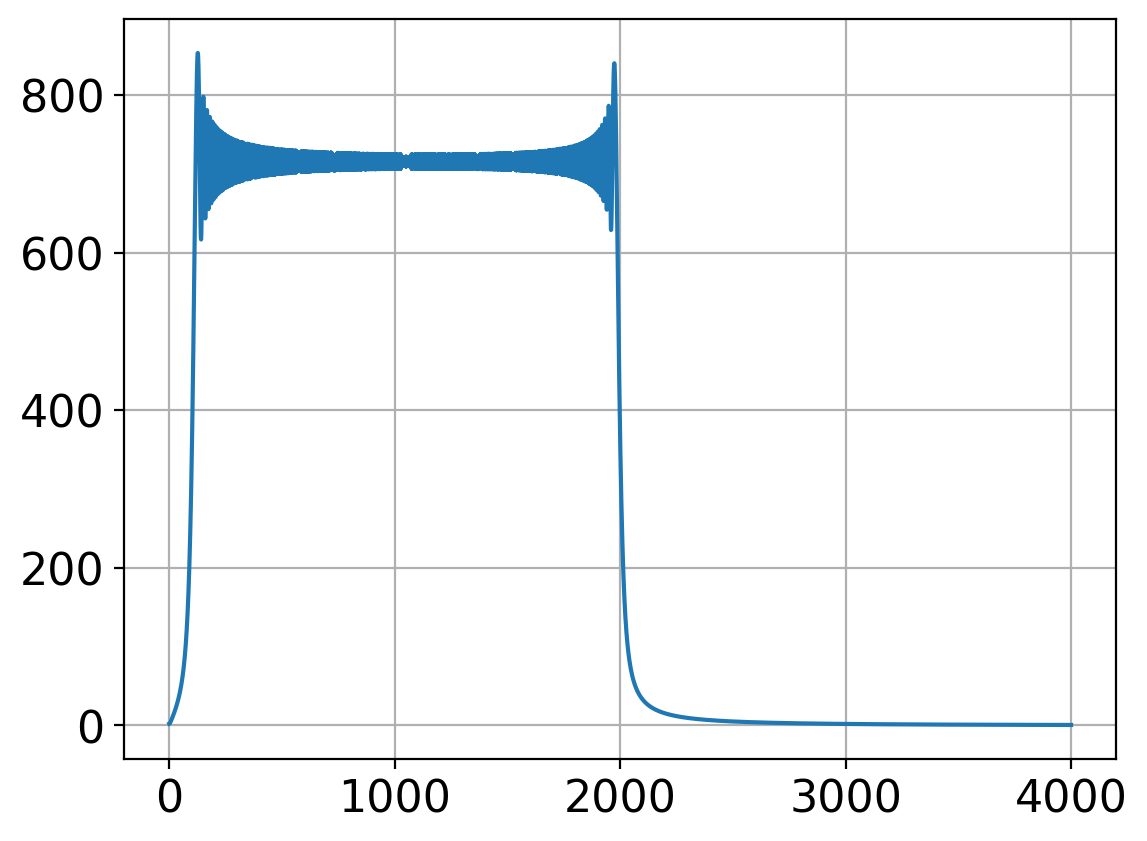

In [48]:

plot_spec(signal,fs,4000);